In [1]:
################################################
# Fraud Detection Pipeline - Step 1: Data Fixing
# Step 2: Feature Engineering  
# Step 3: Model Training
################################################

import pandas as pd
import numpy as np
import pickle
import gc
import warnings
warnings.filterwarnings('ignore')

# Model training
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from lightgbm import LGBMClassifier, early_stopping as lgb_early_stopping

In [2]:
################################################
# Helper Functions - Data Loading
################################################

def load_raw_data(data_dir='../../data'):
    """
    Raw CSV dosyalarını yükle ve birleştir.
    Transaction ve Identity tablolarını merge eder.
    
    Returns:
        df: Birleştirilmiş DataFrame (_source kolonu ile train/test ayrımı)
    """
    # Load
    train_id = pd.read_csv(f'{data_dir}/train_identity.csv')
    test_id = pd.read_csv(f'{data_dir}/test_identity.csv')
    train_tr = pd.read_csv(f'{data_dir}/train_transaction.csv')
    test_tr = pd.read_csv(f'{data_dir}/test_transaction.csv')
    
    # Merge transaction + identity
    train_df = pd.merge(train_tr, train_id, on='TransactionID', how='left')
    test_df = pd.merge(test_tr, test_id, on='TransactionID', how='left')
    
    # Mark source
    train_df['_source'] = 'train'
    test_df['_source'] = 'test'
    
    # Combine
    df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    
    # Cleanup
    del train_id, test_id, train_tr, test_tr, train_df, test_df
    gc.collect()
    
    return df

In [3]:
################################################
# Helper Functions - DType Optimization
################################################

def convert_float_to_int(df):
    """
    Float64 kolonları uygun integer tipine dönüştürür.
    NaN değerler korunur (nullable Int8/16/32).
    """
    converted = {'Int8': [], 'Int16': [], 'Int32': []}
    
    for col in df.select_dtypes(include=['float64']).columns:
        col_min = df[col].min()
        col_max = df[col].max()
        
        # Sadece tam sayı değerler içeriyorsa dönüştür
        if df[col].dropna().apply(lambda x: x == int(x)).all():
            if col_min >= -128 and col_max <= 127:
                df[col] = df[col].astype('Int8')
                converted['Int8'].append(col)
            elif col_min >= -32768 and col_max <= 32767:
                df[col] = df[col].astype('Int16')
                converted['Int16'].append(col)
            elif col_min >= -2147483648 and col_max <= 2147483647:
                df[col] = df[col].astype('Int32')
                converted['Int32'].append(col)
    
    return df, converted


def convert_object_to_category(df, threshold=50):
    """
    Düşük kardinaliteli object kolonları category'ye dönüştürür.
    """
    converted = []
    
    for col in df.select_dtypes(include=['object']).columns:
        if col == '_source':
            continue
        if df[col].nunique() <= threshold:
            df[col] = df[col].astype('category')
            converted.append(col)
    
    return df, converted


def convert_domain_categorical(df):
    """
    Domain bilgisi olan kolonları category'ye dönüştürür.
    ProductCD, card4, card6, P/R_emaildomain gibi.
    """
    domain_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']
    converted = []
    
    for col in domain_cols:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].astype('category')
            converted.append(col)
    
    return df, converted

In [4]:
################################################
# Helper Functions - Feature Engineering
# 04_FeatureEngineering notebook'una uygun yapı
################################################

def create_temporal_features(df):
    """
    Temporal features for aggregations.
    """
    df['day'] = (df['TransactionDT'] // 86400).astype('int16')
    df['week_num'] = (df['TransactionDT'] // 604800).astype('int16')
    df['month_num'] = (df['week_num'] // 4).astype('int16')
    return df


def create_uid_features(df):
    """
    Chris Deotte's UID (User ID) features.
    card1 + addr1 + anchor_day kombinasyonu.
    """
    # D1 filled for anchor calculation
    D1_filled = df['D1'].fillna(0)
    df['anchor_day'] = (df['day'] - D1_filled).astype('int16')
    
    # UID: card1_addr1_anchorday
    df['uid'] = (df['card1'].astype(str) + '_' + 
                 df['addr1'].astype(str) + '_' + 
                 df['anchor_day'].astype(str))
    
    # User anchor D1 (Chris Deotte's approach)
    df['user_anchor_D1'] = df['TransactionDT'] - (D1_filled.astype('float64') * 86400)
    
    return df


def create_uid_aggregations(df):
    """
    UID bazlı aggregation features.
    04_FE'de yüksek korelasyonlu olanlar DROP edildi, sadece gerekli olanlar kalıyor.
    
    KALAN: uid_avg_amt, uid_std_amt, uid_max_amt, uid_total_amt, amt_vs_uid_month_avg
    DROP: uid_txn_count (0.989 corr), uid_week_txn_count (0.895), 
          uid_month_avg_amt (0.969), uid_week_avg_amt (0.833), amt_vs_uid_avg (0.873)
    """
    # General statistics
    uid_agg = df.groupby('uid').agg({
        'TransactionAmt': ['mean', 'std', 'max', 'sum']  # count kaldırıldı
    })
    uid_agg.columns = ['uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 'uid_total_amt']
    uid_agg = uid_agg.reset_index()
    df = df.merge(uid_agg, on='uid', how='left')
    
    # Monthly statistics (for amt_vs_uid_month_avg only)
    uid_month = df.groupby(['uid', 'month_num']).agg({'TransactionAmt': 'mean'})
    uid_month.columns = ['uid_month_avg_amt']
    uid_month = uid_month.reset_index()
    df = df.merge(uid_month, on=['uid', 'month_num'], how='left')
    
    # Anomaly ratio - sadece month avg (uid_avg corr=0.873 ile DROP)
    df['amt_vs_uid_month_avg'] = df['TransactionAmt'] / (df['uid_month_avg_amt'] + 1)
    
    # uid_month_avg_amt kendisi de DROP (0.969 corr with uid_avg_amt)
    df = df.drop(columns=['uid_month_avg_amt'], errors='ignore')
    
    return df


def create_card_aggregations(df):
    """
    Card1 ve Card1+Addr1 aggregation features.
    04_FE'de card1_amt_std DROP edildi (0.813 corr with card1_amt_mean)
    """
    # Card1 aggregations (std hariç)
    card1_agg = df.groupby('card1').agg({
        'TransactionAmt': ['mean', 'max'],  # std kaldırıldı
        'addr1': 'nunique'
    }).reset_index()
    card1_agg.columns = ['card1', 'card1_amt_mean', 'card1_amt_max', 'n_addr']
    df = df.merge(card1_agg, on='card1', how='left')
    
    # n_devices: Card1 başına unique device sayısı
    if 'DeviceInfo' in df.columns:
        device_agg = df.groupby('card1').agg({
            'DeviceInfo': 'nunique'
        }).reset_index()
        device_agg.columns = ['card1', 'n_devices']
        df = df.merge(device_agg, on='card1', how='left')
    
    # Card1_Addr1 combination
    df['card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    card1_addr1_agg = df.groupby('card1_addr1').agg({
        'TransactionAmt': ['mean', 'std']
    }).reset_index()
    card1_addr1_agg.columns = ['card1_addr1', 'card1_addr1_amt_mean', 'card1_addr1_amt_std']
    df = df.merge(card1_addr1_agg, on='card1_addr1', how='left')
    
    # Ratio features
    df['amt_vs_card1_mean'] = df['TransactionAmt'] / (df['card1_amt_mean'] + 1)
    
    return df


def create_frequency_encodings(df):
    """
    Frequency encoding features - _FE formatı (transform count).
    04_FE'deki gibi.
    """
    # Main frequency encodings
    df['card1_FE'] = df.groupby('card1')['card1'].transform('count')
    df['addr1_FE'] = df.groupby('addr1')['addr1'].transform('count')
    df['card1_addr1_FE'] = df.groupby('card1_addr1')['card1_addr1'].transform('count')
    
    # Additional FE for cards
    for col in ['card2', 'card3', 'card5']:
        if col in df.columns:
            df[f'{col}_FE'] = df.groupby(col)[col].transform('count')
    
    # Email domain FE
    if 'P_emaildomain' in df.columns:
        df['P_emaildomain_FE'] = df.groupby('P_emaildomain')['P_emaildomain'].transform('count')
    if 'R_emaildomain' in df.columns:
        df['R_emaildomain_FE'] = df.groupby('R_emaildomain')['R_emaildomain'].transform('count')
    
    return df


def create_freq_encodings_map(df):
    """
    Frequency encoding features - _freq formatı (value_counts map).
    04_FE'deki high cardinality encoding yapısı.
    """
    # Card ve addr frequency encodings
    for col in ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2']:
        if col in df.columns:
            col_str = df[col].astype(str)
            freq_map = col_str.value_counts().to_dict()
            df[f'{col}_freq'] = col_str.map(freq_map).fillna(0).astype('int32')
    
    # Email domain freq
    for col in ['P_emaildomain', 'R_emaildomain']:
        if col in df.columns:
            col_str = df[col].astype(str)
            freq_map = col_str.value_counts().to_dict()
            df[f'{col}_freq'] = col_str.map(freq_map).fillna(0).astype('int32')
    
    return df


def create_amount_features(df):
    """
    Transaction amount features (psychological pricing).
    """
    dollars = df['TransactionAmt'].astype(int)
    cents = ((df['TransactionAmt'] - dollars) * 100).round().astype('int8')
    
    # Round amounts
    is_round = (cents == 0) & ((dollars % 100 == 0) | (dollars % 50 == 0) | (dollars % 10 == 0))
    # Psychological pricing (.99 or .95)
    is_psych = (cents == 99) | (cents == 95)
    # Random amounts (highest fraud signal)
    is_random = ~is_round & ~is_psych
    
    df['is_random_amount'] = is_random.astype('int8')
    
    return df


def encode_categorical_columns(df):
    """
    Kategorik kolonları Label Encoding ile encode et.
    04_FE'deki gibi: ProductCD, card4, card6 kategorik olarak kalıyor.
    """
    from sklearn.preprocessing import LabelEncoder
    
    cat_cols = ['ProductCD', 'card4', 'card6']
    
    for col in cat_cols:
        if col in df.columns:
            le = LabelEncoder()
            # Missing değerleri 'MISSING' olarak işaretle
            df[col] = df[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING', '<NA>': 'MISSING'})
            df[col] = le.fit_transform(df[col])
    
    return df


def fill_engineered_missing(df):
    """
    Fill missing values for engineered features.
    04_FE'deki yapıya uygun.
    """
    agg_cols = ['uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 'uid_total_amt',
                'card1_amt_mean', 'card1_amt_max', 'n_addr', 'n_devices',
                'card1_addr1_amt_mean', 'card1_addr1_amt_std',
                'card1_FE', 'addr1_FE', 'card1_addr1_FE',
                'card2_FE', 'card3_FE', 'card5_FE', 'P_emaildomain_FE', 'R_emaildomain_FE',
                'user_anchor_D1',
                # _freq encodings (high cardinality)
                'card1_freq', 'card2_freq', 'card3_freq', 'card5_freq',
                'addr1_freq', 'addr2_freq', 'P_emaildomain_freq', 'R_emaildomain_freq']
    
    ratio_cols = ['amt_vs_uid_month_avg', 'amt_vs_card1_mean']
    
    for col in agg_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    for col in ratio_cols:
        if col in df.columns:
            df[col] = df[col].fillna(1.0)
    
    # dist1, dist2: -999 ile doldur (04_FE'deki gibi)
    for col in ['dist1', 'dist2']:
        if col in df.columns:
            df[col] = df[col].fillna(-999)
    
    return df


def cleanup_temp_columns(df):
    """
    Remove ONLY temporary columns used for aggregations.
    04_FE'deki yapıya uygun - kategorikler ve ham ID'ler KALACAK.
    
    Silinecekler:
    - Aggregation temp kolonları (day, week_num, month_num, anchor_day, uid, card1_addr1)
    - D1 (user_anchor_D1 oluşturuldu)
    - DeviceInfo (n_devices oluşturuldu)
    - P/R_emaildomain (freq encoding yapıldı)
    
    KALACAKLAR:
    - ProductCD, card4, card6 (label encoded kategorik)
    - card1-5, addr1-2 (_freq versiyonları için ham değerler gerekli değil ama
      04_FE'de bunlar da siliniyor, _freq'ler var)
    - dist1, dist2 (model için)
    """
    # Temp columns (aggregation için)
    temp_cols = ['day', 'week_num', 'month_num', 'anchor_day', 'uid', 'card1_addr1']
    
    # Derived columns
    derived_cols = ['D1', 'DeviceInfo']
    
    # Email domains (_freq var, orijinaller gerekli değil)
    email_cols = ['P_emaildomain', 'R_emaildomain']
    # Email domains (_FE var, orijinaller gerekli değil)
    # Ham ID'ler (_freq versiyonları var, orijinaller gerekli değil)
    raw_ids = ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2']
    # Ham ID'ler (_FE versiyonları var, orijinaller gerekli değil)
    all_drop_cols = temp_cols + derived_cols + email_cols + raw_ids
    
    df = df.drop(columns=[c for c in all_drop_cols if c in df.columns], errors='ignore')
    
    return df

In [5]:
################################################
# Helper Functions - Feature Selection
################################################

# Yorumlanabilir (Interpretable) özellikler listesi
# DeviceInfo ekledik (n_devices için)
INTERPRETABLE_FEATURES = [
    'TransactionID', 'TransactionDT', 'TransactionAmt',
    'isFraud', '_source',
    'ProductCD',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2', 'dist1', 'dist2',
    'P_emaildomain', 'R_emaildomain',
    'D1',
    'DeviceInfo'  # n_devices hesabı için
]


def select_interpretable_features(df, features=INTERPRETABLE_FEATURES):
    """
    Sadece yorumlanabilir özellikleri seçer.
    V, id_, M, C, D2-D15 gibi black-box özellikler çıkarılır.
    """
    available = [col for col in features if col in df.columns]
    df_selected = df[available].copy()
    
    return df_selected, available

In [6]:
################################################
# Helper Functions - Utilities
################################################

def get_memory_mb(df):
    """DataFrame'in bellek kullanımını MB olarak döndürür."""
    return df.memory_usage(deep=True).sum() / 1024**2


def print_dtype_distribution(df, title=""):
    """Dtype dağılımını yazdırır."""
    print(f"\n{'='*50}")
    print(f"{title}")
    print('='*50)
    print(df.dtypes.value_counts())
    print(f"\nColumns: {len(df.columns)} | Memory: {get_memory_mb(df):.1f} MB")

In [7]:
################################################
# Helper Functions - Model Training
################################################

# 05_ModelOptimization'dan Optuna ile bulunan en iyi parametreler
# 50 trial sonucu optimize edilmiş - hedef Val AUC: ~0.88+
BEST_LGBM_PARAMS = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 8,
    'num_leaves': 45,
    'min_child_samples': 80,
    'min_child_weight': 1.0,
    'subsample': 0.7,
    'subsample_freq': 3,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.5,
    'reg_lambda': 1.0,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}


def create_time_features_for_split(df):
    """
    Model split için temporal features oluşturur.
    """
    df['month_num'] = (df['TransactionDT'] // (86400 * 30)).astype('int16')
    return df


def time_based_train_test_split(df, train_ratio=0.6, val_ratio=0.2):
    """
    Time-based train/val/test split.
    Fraud detection için zaman bazlı split kritik - gelecek verisiyle eğitim önlenir.
    """
    # Sort by time
    df = df.sort_values('TransactionDT').reset_index(drop=True)
    
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    
    return train_df, val_df, test_df


def prepare_model_data(train_df, val_df, test_df, target='isFraud'):
    """
    Model için X, y hazırla.
    """
    # Exclude columns
    exclude_cols = ['TransactionID', 'TransactionDT', target, '_source', 'month_num']
    feature_cols = [c for c in train_df.columns if c not in exclude_cols]
    
    X_train = train_df[feature_cols]
    X_val = val_df[feature_cols]
    X_test = test_df[feature_cols]
    
    y_train = train_df[target]
    y_val = val_df[target]
    y_test = test_df[target]
    
    return X_train, X_val, X_test, y_train, y_val, y_test, feature_cols


def train_lightgbm_with_cv(X_train, y_train, X_val, y_val, groups_train, params=None):
    """
    GroupKFold CV ile LightGBM eğitimi.
    Early stopping ile overfitting kontrolü.
    """
    if params is None:
        params = BEST_LGBM_PARAMS.copy()
    
    # Train with early stopping
    model = LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb_early_stopping(50, verbose=False)]
    )
    
    # GroupKFold CV scores
    cv = GroupKFold(n_splits=3)
    X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
    groups_full = np.concatenate([groups_train, np.max(groups_train) + 1 + np.zeros(len(y_val))])
    
    cv_scores = []
    for train_idx, val_idx in cv.split(X_full, y_full, groups=groups_full):
        X_tr, X_vl = X_full.iloc[train_idx], X_full.iloc[val_idx]
        y_tr, y_vl = y_full.iloc[train_idx], y_full.iloc[val_idx]
        
        cv_model = LGBMClassifier(**params)
        cv_model.fit(X_tr, y_tr)
        y_pred = cv_model.predict_proba(X_vl)[:, 1]
        cv_scores.append(roc_auc_score(y_vl, y_pred))
    
    return model, np.array(cv_scores)


def evaluate_model(model, X, y, set_name=""):
    """
    Model performans metrikleri.
    """
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    metrics = {
        'set': set_name,
        'auc': roc_auc_score(y, y_proba),
        'pr_auc': average_precision_score(y, y_proba),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred)
    }
    
    return metrics


def print_model_results(train_metrics, val_metrics, test_metrics, cv_scores):
    """
    Model sonuçlarını yazdır.
    """
    print("\n" + "="*60)
    print("MODEL PERFORMANCE")
    print("="*60)
    
    print(f"\n{'Set':<8} {'AUC':<10} {'PR-AUC':<10} {'Prec':<10} {'Recall':<10} {'F1':<10}")
    print("-"*60)
    for m in [train_metrics, val_metrics, test_metrics]:
        print(f"{m['set']:<8} {m['auc']:<10.4f} {m['pr_auc']:<10.4f} {m['precision']:<10.4f} {m['recall']:<10.4f} {m['f1']:<10.4f}")
    
    print(f"\nGroupKFold CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Overfit Gap (Train-Val): {train_metrics['auc'] - val_metrics['auc']:.4f}")

In [8]:
################################################
# Main Function - Full Pipeline
################################################

def fraud_pipeline(data_dir='../../data'):
    """
    Fraud detection için full pipeline:
    1. Data Fixing (load, select, optimize dtypes)
    2. Feature Engineering (UID, Card, Frequency, Amount)
    3. Model Training (LightGBM with GroupKFold CV)
    
    Returns:
        model: Trained LightGBM model
        df: Processed DataFrame
        results: Model performance metrics
    """
    print("="*60)
    print("FRAUD DETECTION PIPELINE")
    print("="*60)
    
    # ============================================================
    # STEP 1: DATA FIXING
    # ============================================================
    print("\n" + "="*60)
    print("STEP 1: DATA FIXING")
    print("="*60)
    
    # Load raw data
    print("\n[1.1] Loading raw data...")
    df = load_raw_data(data_dir)
    raw_memory = get_memory_mb(df)
    raw_cols = df.shape[1]
    print(f"      Shape: {df.shape[0]:,} x {df.shape[1]}")
    print(f"      Memory: {raw_memory:.0f} MB")
    
    # Feature Selection
    print("\n[1.2] Selecting interpretable features...")
    df, selected_cols = select_interpretable_features(df)
    after_selection = get_memory_mb(df)
    print(f"      {raw_cols} → {df.shape[1]} features")
    print(f"      Memory: {raw_memory:.0f} → {after_selection:.0f} MB")
    
    # DType Optimization
    print("\n[1.3] Optimizing dtypes...")
    df, int_converted = convert_float_to_int(df)
    df, obj_converted = convert_object_to_category(df)
    df, domain_converted = convert_domain_categorical(df)
    after_dtype = get_memory_mb(df)
    print(f"      Float→Int: {sum(len(v) for v in int_converted.values())} cols")
    print(f"      Object→Category: {len(obj_converted)} cols")
    print(f"      Memory: {after_selection:.0f} → {after_dtype:.0f} MB")
    
    # ============================================================
    # STEP 2: FEATURE ENGINEERING
    # ============================================================
    print("\n" + "="*60)
    print("STEP 2: FEATURE ENGINEERING")
    print("="*60)
    
    cols_before = df.shape[1]
    
    # Temporal features
    print("\n[2.1] Creating temporal features...")
    df = create_temporal_features(df)
    
    # UID features
    print("[2.2] Creating UID features...")
    df = create_uid_features(df)
    df = create_uid_aggregations(df)
    
    # Card aggregations
    print("[2.3] Creating card aggregations...")
    df = create_card_aggregations(df)
    
    # Frequency encodings (_FE format - 04_FE'deki gibi)
    print("[2.4] Creating frequency encodings (_FE)...")
    df = create_frequency_encodings(df)
    
    # Frequency encodings (_freq format - high cardinality için)
    print("[2.5] Creating frequency encodings (_freq)...")
    df = create_freq_encodings_map(df)
    
    # Amount features
    print("[2.6] Creating amount features...")
    df = create_amount_features(df)
    
    # Categorical encoding (ProductCD, card4, card6)
    print("[2.7] Encoding categorical columns...")
    df = encode_categorical_columns(df)
    
    # Fill missing and cleanup
    print("[2.8] Filling missing values and cleanup...")
    df = fill_engineered_missing(df)
    df = cleanup_temp_columns(df)
    
    new_features = df.shape[1] - cols_before + 6
    print(f"\n      New features: +{new_features}")
    print(f"      Total features: {df.shape[1]}")
    
    # ============================================================
    # STEP 3: MODEL TRAINING
    # ============================================================
    print("\n" + "="*60)
    print("STEP 3: MODEL TRAINING")
    print("="*60)
    
    # Filter train only (test has no isFraud)
    print("\n[3.1] Preparing train data...")
    df_train = df[df['_source'] == 'train'].copy()
    df_test_submission = df[df['_source'] == 'test'].copy()
    print(f"      Train samples: {len(df_train):,}")
    print(f"      Test samples (submission): {len(df_test_submission):,}")
    
    # Time-based split
    print("\n[3.2] Time-based train/val/test split...")
    df_train = create_time_features_for_split(df_train)
    train_df, val_df, test_df = time_based_train_test_split(df_train)
    print(f"      Train: {len(train_df):,} ({len(train_df)/len(df_train)*100:.0f}%)")
    print(f"      Val:   {len(val_df):,} ({len(val_df)/len(df_train)*100:.0f}%)")
    print(f"      Test:  {len(test_df):,} ({len(test_df)/len(df_train)*100:.0f}%)")
    
    # Prepare X, y
    X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = prepare_model_data(
        train_df, val_df, test_df
    )
    print(f"\n      Features for model: {len(feature_cols)}")
    print(f"      Fraud rate - Train: {y_train.mean()*100:.2f}%")
    print(f"      Fraud rate - Val:   {y_val.mean()*100:.2f}%")
    print(f"      Fraud rate - Test:  {y_test.mean()*100:.2f}%")
    
    # Train LightGBM
    print("\n[3.3] Training LightGBM with GroupKFold CV...")
    groups_train = train_df['month_num'].values
    model, cv_scores = train_lightgbm_with_cv(X_train, y_train, X_val, y_val, groups_train)
    
    # Evaluate
    print("\n[3.4] Evaluating model...")
    train_metrics = evaluate_model(model, X_train, y_train, "Train")
    val_metrics = evaluate_model(model, X_val, y_val, "Val")
    test_metrics = evaluate_model(model, X_test, y_test, "Test")
    
    print_model_results(train_metrics, val_metrics, test_metrics, cv_scores)
    
    # ============================================================
    # SUMMARY
    # ============================================================
    final_memory = get_memory_mb(df)
    
    print("\n" + "="*60)
    print("PIPELINE SUMMARY")
    print("="*60)
    print(f"Raw Data:        {raw_memory:.0f} MB ({raw_cols} features)")
    print(f"Final Data:      {final_memory:.0f} MB ({df.shape[1]} features)")
    print(f"Model Val AUC:   {val_metrics['auc']:.4f}")
    print(f"Model Test AUC:  {test_metrics['auc']:.4f}")
    print(f"CV AUC:          {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    results = {
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'cv_scores': cv_scores,
        'feature_cols': feature_cols
    }
    
    return model, df, results

In [9]:
################################################
# Pipeline Execution
################################################

model, df, results = fraud_pipeline(data_dir='../../data')

FRAUD DETECTION PIPELINE

STEP 1: DATA FIXING

[1.1] Loading raw data...
      Shape: 1,097,231 x 473
      Memory: 5433 MB

[1.2] Selecting interpretable features...
      473 → 20 features
      Memory: 5433 → 469 MB

[1.3] Optimizing dtypes...
      Float→Int: 9 cols
      Object→Category: 3 cols
      Memory: 469 → 161 MB

STEP 2: FEATURE ENGINEERING

[2.1] Creating temporal features...
[2.2] Creating UID features...
[2.3] Creating card aggregations...
[2.4] Creating frequency encodings (_FE)...
[2.5] Creating frequency encodings (_freq)...
[2.6] Creating amount features...
[2.7] Encoding categorical columns...
[2.8] Filling missing values and cleanup...

      New features: +26
      Total features: 40

STEP 3: MODEL TRAINING

[3.1] Preparing train data...
      Train samples: 590,540
      Test samples (submission): 506,691

[3.2] Time-based train/val/test split...
      Train: 354,324 (60%)
      Val:   118,108 (20%)
      Test:  118,108 (20%)

      Features for model: 36
     

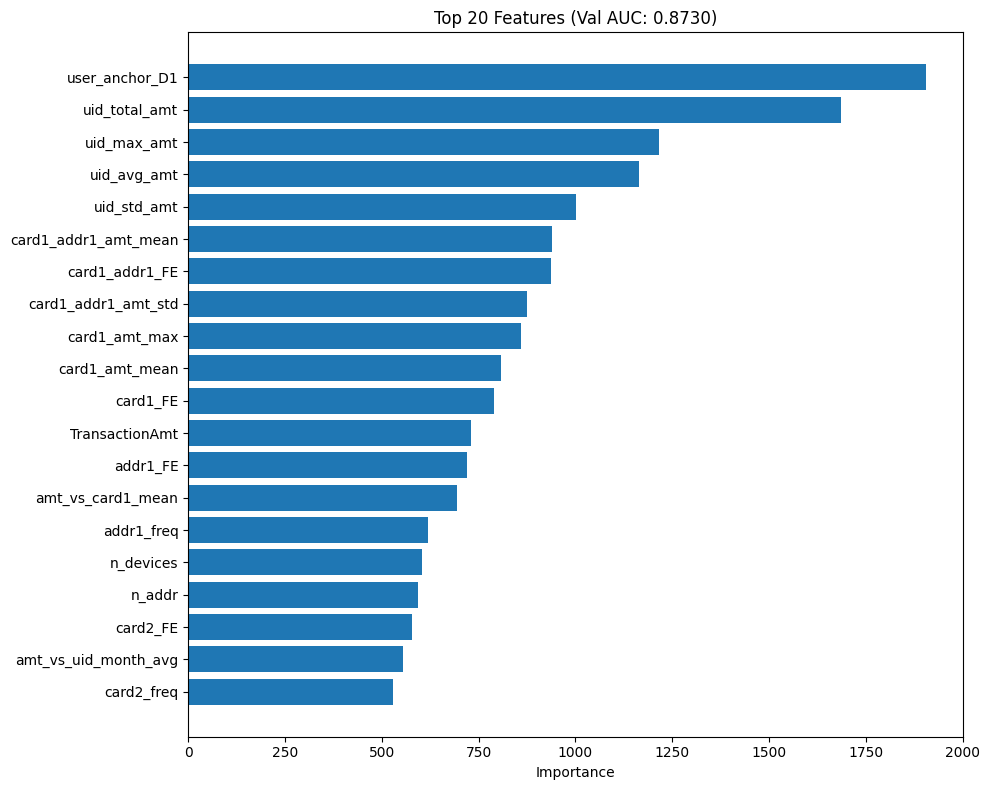


Top 10 Features:
  user_anchor_D1                 : 1905
  uid_total_amt                  : 1685
  uid_max_amt                    : 1216
  uid_avg_amt                    : 1165
  uid_std_amt                    : 1002
  card1_addr1_amt_mean           : 940
  card1_addr1_FE                 : 938
  card1_addr1_amt_std            : 876
  card1_amt_max                  : 859
  card1_amt_mean                 : 807


In [10]:
################################################
# Output - Feature Importance
################################################

import matplotlib.pyplot as plt

# Feature importance
importance = pd.DataFrame({
    'feature': results['feature_cols'],
    'importance': model.feature_importances_
}).nlargest(20, 'importance')

plt.figure(figsize=(10, 8))
plt.barh(range(len(importance)), importance['importance'].values)
plt.yticks(range(len(importance)), importance['feature'].values)
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title(f'Top 20 Features (Val AUC: {results["val_metrics"]["auc"]:.4f})')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
for i, row in importance.head(10).iterrows():
    print(f"  {row['feature']:<30} : {row['importance']:.0f}")

In [11]:
################################################
# Sklearn Pipeline Version - Custom Transformers
################################################

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn import set_config

# Enable HTML diagram display
set_config(display='diagram')


class TemporalFeatureCreator(BaseEstimator, TransformerMixin):
    """Temporal features: day, week_num, month_num"""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X['day'] = (X['TransactionDT'] // 86400).astype('int16')
        X['week_num'] = (X['TransactionDT'] // 604800).astype('int16')
        X['month_num'] = (X['week_num'] // 4).astype('int16')
        return X


class UIDFeatureCreator(BaseEstimator, TransformerMixin):
    """UID features: card1_addr1_anchor combination + user_anchor_D1"""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        D1_filled = X['D1'].fillna(0) if 'D1' in X.columns else 0
        X['anchor_day'] = (X['day'] - D1_filled).astype('int16')
        X['uid'] = (X['card1'].astype(str) + '_' + 
                   X['addr1'].astype(str) + '_' + 
                   X['anchor_day'].astype(str))
        # user_anchor_D1 (Chris Deotte's approach)
        X['user_anchor_D1'] = X['TransactionDT'] - (D1_filled.astype('float64') * 86400)
        return X


class UIDAggregationCreator(BaseEstimator, TransformerMixin):
    """UID aggregation features: avg, std, max, sum + monthly ratio"""
    def __init__(self):
        self.uid_stats_ = None
        self.uid_month_stats_ = None
    
    def fit(self, X, y=None):
        # General UID statistics
        self.uid_stats_ = X.groupby('uid')['TransactionAmt'].agg(['mean', 'std', 'max', 'sum'])
        self.uid_stats_.columns = ['uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 'uid_total_amt']
        
        # Monthly UID statistics (for amt_vs_uid_month_avg)
        self.uid_month_stats_ = X.groupby(['uid', 'month_num'])['TransactionAmt'].mean()
        self.uid_month_stats_.name = 'uid_month_avg_amt'
        return self
    
    def transform(self, X):
        X = X.copy()
        X = X.merge(self.uid_stats_, on='uid', how='left')
        X = X.merge(self.uid_month_stats_.reset_index(), on=['uid', 'month_num'], how='left')
        
        # Anomaly ratio
        X['amt_vs_uid_month_avg'] = X['TransactionAmt'] / (X['uid_month_avg_amt'] + 1)
        X = X.drop(columns=['uid_month_avg_amt'], errors='ignore')
        
        # Fill missing
        for col in ['uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 'uid_total_amt']:
            X[col] = X[col].fillna(0)
        X['amt_vs_uid_month_avg'] = X['amt_vs_uid_month_avg'].fillna(1.0)
        return X


class CardAggregationCreator(BaseEstimator, TransformerMixin):
    """Card1 aggregation features: amt_mean, amt_max, n_addr, n_devices"""
    def __init__(self):
        self.card1_stats_ = None
        self.card1_addr_stats_ = None
        self.card1_device_stats_ = None
        self.card1_addr1_stats_ = None
    
    def fit(self, X, y=None):
        # Card1 amount stats
        self.card1_stats_ = X.groupby('card1')['TransactionAmt'].agg(['mean', 'max'])
        self.card1_stats_.columns = ['card1_amt_mean', 'card1_amt_max']
        
        # n_addr: unique addr1 per card1
        self.card1_addr_stats_ = X.groupby('card1')['addr1'].nunique()
        self.card1_addr_stats_.name = 'n_addr'
        
        # n_devices: unique DeviceInfo per card1
        if 'DeviceInfo' in X.columns:
            self.card1_device_stats_ = X.groupby('card1')['DeviceInfo'].nunique()
            self.card1_device_stats_.name = 'n_devices'
        
        # Card1_Addr1 combination stats
        X_temp = X.copy()
        X_temp['card1_addr1'] = X_temp['card1'].astype(str) + '_' + X_temp['addr1'].astype(str)
        self.card1_addr1_stats_ = X_temp.groupby('card1_addr1')['TransactionAmt'].agg(['mean', 'std'])
        self.card1_addr1_stats_.columns = ['card1_addr1_amt_mean', 'card1_addr1_amt_std']
        return self
    
    def transform(self, X):
        X = X.copy()
        X['card1_addr1'] = X['card1'].astype(str) + '_' + X['addr1'].astype(str)
        
        X = X.merge(self.card1_stats_, on='card1', how='left')
        X = X.merge(self.card1_addr_stats_.reset_index(), on='card1', how='left')
        
        if self.card1_device_stats_ is not None:
            X = X.merge(self.card1_device_stats_.reset_index(), on='card1', how='left')
        
        X = X.merge(self.card1_addr1_stats_, on='card1_addr1', how='left')
        
        # Ratio feature
        X['amt_vs_card1_mean'] = X['TransactionAmt'] / (X['card1_amt_mean'] + 1)
        
        # Fill missing
        for col in ['card1_amt_mean', 'card1_amt_max', 'n_addr', 'n_devices', 
                    'card1_addr1_amt_mean', 'card1_addr1_amt_std']:
            if col in X.columns:
                X[col] = X[col].fillna(0)
        X['amt_vs_card1_mean'] = X['amt_vs_card1_mean'].fillna(1.0)
        return X


class FrequencyEncoderFE(BaseEstimator, TransformerMixin):
    """Frequency encoding _FE format (transform count)"""
    def __init__(self):
        self.freq_counts_ = {}
    
    def fit(self, X, y=None):
        # Count frequencies for each column
        for col in ['card1', 'card2', 'card3', 'card5', 'addr1']:
            if col in X.columns:
                self.freq_counts_[col] = X[col].value_counts().to_dict()
        
        # card1_addr1 combination
        if 'card1_addr1' in X.columns:
            self.freq_counts_['card1_addr1'] = X['card1_addr1'].value_counts().to_dict()
        
        # Email domains
        for col in ['P_emaildomain', 'R_emaildomain']:
            if col in X.columns:
                self.freq_counts_[col] = X[col].value_counts().to_dict()
        return self
    
    def transform(self, X):
        X = X.copy()
        for col, freq_map in self.freq_counts_.items():
            if col in X.columns:
                X[f'{col}_FE'] = X[col].map(freq_map).fillna(0).astype('int32')
        return X


class FrequencyEncoderFreq(BaseEstimator, TransformerMixin):
    """Frequency encoding _freq format (value_counts map)"""
    def __init__(self, columns=None):
        self.columns = columns or ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2',
                                    'P_emaildomain', 'R_emaildomain']
        self.freq_maps_ = {}
    
    def fit(self, X, y=None):
        for col in self.columns:
            if col in X.columns:
                self.freq_maps_[col] = X[col].astype(str).value_counts().to_dict()
        return self
    
    def transform(self, X):
        X = X.copy()
        for col, freq_map in self.freq_maps_.items():
            if col in X.columns:
                X[f'{col}_freq'] = X[col].astype(str).map(freq_map).fillna(0).astype('int32')
        return X


class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """Label encoding for categorical columns (ProductCD, card4, card6)"""
    def __init__(self, columns=None):
        self.columns = columns or ['ProductCD', 'card4', 'card6']
        self.encoders_ = {}
    
    def fit(self, X, y=None):
        for col in self.columns:
            if col in X.columns:
                le = LabelEncoder()
                col_values = X[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING', '<NA>': 'MISSING'})
                le.fit(col_values)
                self.encoders_[col] = le
        return self
    
    def transform(self, X):
        X = X.copy()
        for col, le in self.encoders_.items():
            if col in X.columns:
                col_values = X[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING', '<NA>': 'MISSING'})
                X[col] = col_values.apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
        return X


class AmountFeatureCreator(BaseEstimator, TransformerMixin):
    """Amount-based features: is_random_amount"""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        dollars = X['TransactionAmt'].astype(int)
        cents = ((X['TransactionAmt'] - dollars) * 100).round().astype('int8')
        
        is_round = (cents == 0) & ((dollars % 100 == 0) | (dollars % 50 == 0) | (dollars % 10 == 0))
        is_psych = (cents == 99) | (cents == 95)
        X['is_random_amount'] = (~is_round & ~is_psych).astype('int8')
        return X


class MissingValueFiller(BaseEstimator, TransformerMixin):
    """Fill missing values for dist1, dist2 and other features"""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # dist1, dist2: -999 ile doldur
        for col in ['dist1', 'dist2']:
            if col in X.columns:
                X[col] = X[col].fillna(-999)
        
        # user_anchor_D1
        if 'user_anchor_D1' in X.columns:
            X['user_anchor_D1'] = X['user_anchor_D1'].fillna(0)
        return X


class FeatureCleanup(BaseEstimator, TransformerMixin):
    """Remove temporary columns and prepare for model"""
    def __init__(self, drop_cols=None):
        self.drop_cols = drop_cols or [
            'day', 'week_num', 'month_num', 'anchor_day', 'uid', 'card1_addr1',
            'D1', 'DeviceInfo', 'P_emaildomain', 'R_emaildomain',
            'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2'
        ]
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        cols_to_drop = [c for c in self.drop_cols if c in X.columns]
        return X.drop(columns=cols_to_drop, errors='ignore')


# Build the complete sklearn Pipeline
fraud_pipeline_sklearn = Pipeline([
    ('temporal', TemporalFeatureCreator()),
    ('uid', UIDFeatureCreator()),
    ('uid_agg', UIDAggregationCreator()),
    ('card_agg', CardAggregationCreator()),
    ('freq_fe', FrequencyEncoderFE()),
    ('freq_map', FrequencyEncoderFreq()),
    ('categorical', CategoricalEncoder()),
    ('amount', AmountFeatureCreator()),
    ('missing', MissingValueFiller()),
    ('cleanup', FeatureCleanup()),
])

# Display pipeline diagram
print("Fraud Detection Feature Engineering Pipeline (Complete):")
fraud_pipeline_sklearn

Fraud Detection Feature Engineering Pipeline (Complete):


,steps,"[('temporal', ...), ('uid', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,columns,"['card1', 'card2', ...]"
,columns,"['ProductCD', 'card4', ...]"
,drop_cols,"['day', 'week_num', ...]"


In [14]:
################################################
# Pipeline Usage Example - Raw Data
################################################

# Raw test verisini yükle
raw_test = pd.read_csv('../../data/test_transaction.csv', nrows=10)
raw_test_id = pd.read_csv('../../data/test_identity.csv')
raw_test = raw_test.merge(raw_test_id, on='TransactionID', how='left')

# Interpretable features seç
raw_test, _ = select_interpretable_features(raw_test)

# sklearn pipeline ile transform et (önce fit edilmeli)
fraud_pipeline_sklearn.fit(raw_test)  # fit on sample for demo
X_transformed = fraud_pipeline_sklearn.transform(raw_test)

# Model için feature'ları seç
exclude = ['TransactionID', 'TransactionDT', 'isFraud', '_source']
feature_cols = [c for c in X_transformed.columns if c not in exclude]

# Predict
probs = model.predict_proba(X_transformed[feature_cols])[:, 1]

print("Raw Test Data Predictions:")
for tid, prob in zip(raw_test['TransactionID'], probs):
    print(f"  {tid}: {prob:.4f} {'FRAUD' if prob > 0.5 else 'OK'}")

Raw Test Data Predictions:
  3663549: 0.0747 OK
  3663550: 0.1334 OK
  3663551: 0.1953 OK
  3663552: 0.7053 FRAUD
  3663553: 0.2794 OK
  3663554: 0.2401 OK
  3663555: 0.1829 OK
  3663556: 0.8254 FRAUD
  3663557: 0.2115 OK
  3663558: 0.2757 OK


In [ ]:
################################################
# Save Model and Data
################################################

import os

# Create output directory
output_dir = '../../models/pipeline'
os.makedirs(output_dir, exist_ok=True)

# Save model
with open(f'{output_dir}/lightgbm_pipeline.pkl', 'wb') as f:
    pickle.dump(model, f)
print(f"✓ Model saved: {output_dir}/lightgbm_pipeline.pkl")

# Save processed data
with open('../../data/fraud_data_engineered.pkl', 'wb') as f:
    pickle.dump(df, f)
print(f"✓ Data saved: ../../data/fraud_data_engineered.pkl ({get_memory_mb(df):.0f} MB)")

# Save metadata
import json
metadata = {
    'val_auc': results['val_metrics']['auc'],
    'test_auc': results['test_metrics']['auc'],
    'cv_mean': float(results['cv_scores'].mean()),
    'cv_std': float(results['cv_scores'].std()),
    'n_features': len(results['feature_cols']),
    'feature_cols': results['feature_cols'],
    'params': BEST_LGBM_PARAMS
}

with open(f'{output_dir}/pipeline_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved: {output_dir}/pipeline_metadata.json")

✓ Model saved: ../../models/pipeline/lightgbm_pipeline.pkl
✓ Data saved: ../../data/fraud_data_engineered.pkl (329 MB)
✓ Metadata saved: ../../models/pipeline/pipeline_metadata.json
